# Optional Bonus Challenges 3-5

## Advanced Enhancements to the Content Moderation System

This notebook contains three bonus challenges that extend the core content moderation system with advanced capabilities:

- **Bonus 3**: Performance Optimization - Timing, caching, and parallelization metrics
- **Bonus 4**: Explainability Dashboard - Visual decision breakdowns and confidence scores
- **Bonus 5**: Iterative Re-evaluation - Automatic loop until content is approved

Each bonus builds on the core system without modifying existing agents or graph structure.

## Setup: Import Core System & Dependencies

First, we import the necessary libraries and load the core moderation system components.

In [25]:
!pip install matplotlib

In [26]:
import time
import json
from functools import wraps
from typing import Callable, Dict, Any, List
from collections import defaultdict
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt


print("✅ All dependencies imported successfully!")


✅ All dependencies imported successfully!


## Setup: Define Core Data Structures & Helper Functions

We'll define the ModerationState and core helper functions needed for all bonuses.

In [27]:
from typing import TypedDict, Annotated
from operator import add

# Define the moderation state
def merge_dict(existing, new):
    if existing is None:
        return new
    if new is None:
        return existing
    existing.update(new)
    return existing

def merge_or_take_latest(existing, new):
    return new if new is not None else existing

class ModerationState(TypedDict):
    content: str
    content_type: str
    safety_analysis: Annotated[dict, merge_dict]
    tone_analysis: Annotated[dict, merge_dict]
    grammar_analysis: Annotated[dict, merge_dict]
    overall_score: Annotated[float, merge_or_take_latest]
    decision: Annotated[str, merge_or_take_latest]
    improvement_suggestions: Annotated[list, add]
    enhanced_content: Annotated[str, merge_or_take_latest]
    metadata: Annotated[dict, merge_dict]

print("✅ ModerationState TypedDict defined with proper reducers")

✅ ModerationState TypedDict defined with proper reducers


## Setup: Define Core Agent Functions

These are simplified versions of the core moderation agents from the main system.

In [28]:
# Core Agent Functions

def router_agent(state: ModerationState) -> Dict[str, Any]:
    """Classifies content type (social_media, article, comment)"""
    content_type_map = {
        'social_media': ['like', 'follow', 'share', 'hashtag', '@', 'tweet', 'posted', 'update'],
        'article': ['section', 'paragraph', 'conclusion', 'abstract', 'introduction', 'research'],
        'comment': ['reply', 'respond', 'post', 'comment', 'feedback']
    }
    content = state.get('content', '').lower()
    
    for ctype, keywords in content_type_map.items():
        if any(keyword in content for keyword in keywords):
            return {'content_type': ctype}
    return {'content_type': 'comment'}

def safety_checker_agent(state: ModerationState) -> Dict[str, Any]:
    """Analyzes content for harmful/toxic language"""
    content = state.get('content', '').lower()
    harmful_keywords = ['hate', 'violence', 'abuse', 'toxic', 'offensive', 'stupid', 'terrible']
    risk_level = 'low'
    
    harmful_count = sum(content.count(kw) for kw in harmful_keywords)
    
    if harmful_count > 3:
        risk_level = 'high'
    elif harmful_count > 1:
        risk_level = 'medium'
    
    return {
        'safety_analysis': {
            'risk_level': risk_level,
            'harmful_content_count': harmful_count,
            'safe_for_all_ages': risk_level == 'low'
        }
    }

def tone_analyzer_agent(state: ModerationState) -> Dict[str, Any]:
    """Analyzes sentiment and professionalism"""
    content = state.get('content', '')
    positive_words = ['great', 'wonderful', 'excellent', 'good', 'love', 'amazing', 'fantastic']
    negative_words = ['hate', 'terrible', 'awful', 'bad', 'angry', 'stupid']
    
    pos_count = sum(content.lower().count(word) for word in positive_words)
    neg_count = sum(content.lower().count(word) for word in negative_words)
    
    sentiment_score = min(100, max(0, 50 + (pos_count - neg_count) * 10))
    professionalism = min(100, max(0, 60 + len(content) // 10))
    
    return {
        'tone_analysis': {
            'sentiment_score': sentiment_score,
            'professionalism_score': professionalism
        }
    }

def grammar_checker_agent(state: ModerationState) -> Dict[str, Any]:
    """Checks grammar and clarity"""
    content = state.get('content', '')
    sentences = content.split('.')
    avg_word_count = np.mean([len(s.split()) for s in sentences if s.strip()]) if sentences else 1
    clarity_score = min(100, max(0, 50 + (avg_word_count - 3) * 5))
    
    # Simple error detection
    error_count = max(0, 5 - len(content) // 20)
    
    return {
        'grammar_analysis': {
            'error_count': error_count,
            'clarity_score': clarity_score,
            'avg_word_count': avg_word_count
        }
    }

def evaluator_agent(state: ModerationState) -> Dict[str, Any]:
    """Evaluates and makes approval/rejection decision"""
    safety_score = 95 if state.get('safety_analysis', {}).get('risk_level') == 'low' else \
                   60 if state.get('safety_analysis', {}).get('risk_level') == 'medium' else 20
    
    tone_score = state.get('tone_analysis', {}).get('sentiment_score', 50)
    grammar_score = state.get('grammar_analysis', {}).get('clarity_score', 50)
    
    # Weighted scoring
    weighted_score = 0.4 * safety_score + 0.35 * tone_score + 0.25 * grammar_score
    
    decision = 'APPROVE' if weighted_score >= 70 else 'REJECT'
    
    return {
        'overall_score': weighted_score,
        'decision': decision
    }

def enhancer_agent(state: ModerationState) -> Dict[str, Any]:
    """Enhances approved content"""
    if state.get('decision') == 'APPROVE':
        enhanced = state.get('content', '') + "\n[Enhanced for clarity and impact]"
        return {'enhanced_content': enhanced}
    return {'enhanced_content': state.get('content', '')}

print("✅ All core agent functions defined")

✅ All core agent functions defined


## Setup: Build Core Moderation Graph

Create the LangGraph StateGraph for the core moderation pipeline.

In [29]:
from langgraph.graph import StateGraph, END, START

def build_core_moderation_graph():
    """Builds the core moderation graph"""
    workflow = StateGraph(ModerationState)
    
    workflow.add_node("router", router_agent)
    workflow.add_node("safety_checker", safety_checker_agent)
    workflow.add_node("tone_analyzer", tone_analyzer_agent)
    workflow.add_node("grammar_checker", grammar_checker_agent)
    workflow.add_node("evaluator", evaluator_agent)
    workflow.add_node("enhancer", enhancer_agent)
    
    # Edges
    workflow.add_edge(START, "router")
    workflow.add_edge("router", "safety_checker")
    workflow.add_edge("router", "tone_analyzer")
    workflow.add_edge("router", "grammar_checker")
    workflow.add_edge("safety_checker", "evaluator")
    workflow.add_edge("tone_analyzer", "evaluator")
    workflow.add_edge("grammar_checker", "evaluator")
    
    # Conditional routing based on decision
    def route_decision(state):
        if state.get('decision') == 'REJECT':
            return END
        return 'enhancer'
    
    workflow.add_conditional_edges("evaluator", route_decision, {END: END, 'enhancer': 'enhancer'})
    workflow.add_edge("enhancer", END)
    
    return workflow.compile()

core_graph = build_core_moderation_graph()
print("✅ Core moderation graph created and compiled")

✅ Core moderation graph created and compiled


## Setup: Test Helper Function

Define a helper function for running the graph and displaying results.

In [30]:
def run_moderation(content: str) -> Dict[str, Any]:
    """Run moderation on content and return results"""
    initial_state = {
        'content': content,
        'content_type': '',
        'safety_analysis': {},
        'tone_analysis': {},
        'grammar_analysis': {},
        'overall_score': 0.0,
        'decision': '',
        'improvement_suggestions': [],
        'enhanced_content': '',
        'metadata': {}
    }
    return core_graph.invoke(initial_state)

print("✅ Test helper function defined")

✅ Test helper function defined


---

## Bonus 3: Performance Optimization

### Overview
This bonus adds performance instrumentation to track execution times, implement caching, and analyze parallelization benefits across the moderation pipeline.

### Objectives
1. Measure execution time of each agent
2. Implement content-based caching to avoid redundant processing
3. Track parallelization metrics (concurrent vs sequential timing)
4. Generate performance analytics and bottleneck analysis

### Implementation Pattern
- **Decorator Pattern**: Wrap agents with timing instrumentation
- **Caching Strategy**: Hash-based content caching with hit rate tracking
- **Metrics Collection**: Store timing data per agent across multiple runs

### Setup Performance Tracking Infrastructure

In [31]:
# Performance tracking infrastructure
performance_metrics = defaultdict(list)
content_cache = {}
agent_execution_times = defaultdict(list)

def performance_timer(agent_name: str) -> Callable:
    """Decorator to measure execution time of agents"""
    def decorator(func: Callable) -> Callable:
        @wraps(func)
        def wrapper(state: ModerationState) -> Dict[str, Any]:
            start_time = time.time()
            result = func(state)
            elapsed_time = time.time() - start_time
            
            agent_execution_times[agent_name].append(elapsed_time)
            performance_metrics[agent_name].append({
                'timestamp': datetime.now().isoformat(),
                'elapsed_time': elapsed_time,
                'content_length': len(state.get('content', ''))
            })
            
            return result
        return wrapper
    return decorator

def cache_content(func: Callable) -> Callable:
    """Decorator to cache results for identical content"""
    @wraps(func)
    def wrapper(state: ModerationState) -> Dict[str, Any]:
        content = state.get('content', '')
        cache_key = f"{func.__name__}:{hash(content)}"
        
        if cache_key in content_cache:
            return content_cache[cache_key]
        
        result = func(state)
        content_cache[cache_key] = result
        return result
    return wrapper

print("✅ Performance tracking infrastructure created")
print(f"   • Performance metrics store: enabled")
print(f"   • Content caching: enabled")
print(f"   • Timing decorators: ready")

✅ Performance tracking infrastructure created
   • Performance metrics store: enabled
   • Content caching: enabled
   • Timing decorators: ready


### Build Performance-Tracked Graph

In [32]:
# Create timed versions of agents
timed_router = performance_timer("router")(router_agent)
timed_safety = performance_timer("safety_checker")(cache_content(safety_checker_agent))
timed_tone = performance_timer("tone_analyzer")(cache_content(tone_analyzer_agent))
timed_grammar = performance_timer("grammar_checker")(cache_content(grammar_checker_agent))
timed_evaluator = performance_timer("evaluator")(evaluator_agent)
timed_enhancer = performance_timer("enhancer")(enhancer_agent)

def build_performance_graph():
    """Builds graph with performance instrumentation"""
    workflow = StateGraph(ModerationState)
    
    workflow.add_node("router", timed_router)
    workflow.add_node("safety_checker", timed_safety)
    workflow.add_node("tone_analyzer", timed_tone)
    workflow.add_node("grammar_checker", timed_grammar)
    workflow.add_node("evaluator", timed_evaluator)
    workflow.add_node("enhancer", timed_enhancer)
    
    workflow.add_edge(START, "router")
    workflow.add_edge("router", "safety_checker")
    workflow.add_edge("router", "tone_analyzer")
    workflow.add_edge("router", "grammar_checker")
    workflow.add_edge("safety_checker", "evaluator")
    workflow.add_edge("tone_analyzer", "evaluator")
    workflow.add_edge("grammar_checker", "evaluator")
    
    def route_decision(state):
        return END if state.get('decision') == 'REJECT' else 'enhancer'
    
    workflow.add_conditional_edges("evaluator", route_decision, {END: END, 'enhancer': 'enhancer'})
    workflow.add_edge("enhancer", END)
    
    return workflow.compile()

performance_graph = build_performance_graph()
print("✅ Performance-tracked graph built and compiled")

✅ Performance-tracked graph built and compiled


### Bonus 3: Test Performance Optimization

In [33]:
print("\n" + "="*80)
print("BONUS 3: PERFORMANCE OPTIMIZATION TEST")
print("="*80)

perf_test_cases = [
    "I absolutely love this product! It's fantastic and amazing.",
    "This is terrible and I hate it. Complete waste of money.",
    "Professional article discussing market trends and algorithms.",
    "Quick update: just posted a new photo! #awesome",
    # Test cache: rerun first one
    "I absolutely love this product! It's fantastic and amazing."
]

perf_results = {}
total_times = []

print("\n🧪 Running performance tests...\n")

for i, test_content in enumerate(perf_test_cases, 1):
    print(f"Test {i}: {test_content[:45]}...")
    
    initial_state = {
        'content': test_content,
        'content_type': '',
        'safety_analysis': {},
        'tone_analysis': {},
        'grammar_analysis': {},
        'overall_score': 0.0,
        'decision': '',
        'improvement_suggestions': [],
        'enhanced_content': '',
        'metadata': {}
    }
    
    start = time.time()
    result = performance_graph.invoke(initial_state)
    total_time = time.time() - start
    total_times.append(total_time)
    
    print(f"  └─ Score: {result['overall_score']:.1f} | Decision: {result['decision']} | Time: {total_time*1000:.2f}ms")
    perf_results[f"case_{i}"] = {'score': result['overall_score'], 'time': total_time}

print("\n" + "="*80)
print("📊 PERFORMANCE ANALYTICS")
print("="*80)
print(f"Average Execution Time: {np.mean(total_times)*1000:.2f}ms")
print(f"Min: {min(total_times)*1000:.2f}ms | Max: {max(total_times)*1000:.2f}ms")
print(f"Total Requests: {len(perf_test_cases)}")
print(f"Cache Entries: {len(content_cache)}")
print(f"Parallelization: ✓ 3 analyzers running concurrently (Safety, Tone, Grammar)")

print("\n🔧 AGENT PERFORMANCE BREAKDOWN:")
for agent_name in ['router', 'safety_checker', 'tone_analyzer', 'grammar_checker', 'evaluator', 'enhancer']:
    times = agent_execution_times[agent_name]
    if times:
        avg_time = np.mean(times) * 1000
        print(f"  • {agent_name:20s}: avg {avg_time:6.2f}ms (runs: {len(times)})")

print("\n✅ Bonus 3: Performance Optimization Complete!")


BONUS 3: PERFORMANCE OPTIMIZATION TEST

🧪 Running performance tests...

Test 1: I absolutely love this product! It's fantasti...
  └─ Score: 86.0 | Decision: APPROVE | Time: 14.99ms
Test 2: This is terrible and I hate it. Complete wast...
  └─ Score: 50.1 | Decision: REJECT | Time: 12.73ms
Test 3: Professional article discussing market trends...
  └─ Score: 73.0 | Decision: APPROVE | Time: 15.03ms
Test 4: Quick update: just posted a new photo! #aweso...
  └─ Score: 74.2 | Decision: APPROVE | Time: 14.95ms
Test 5: I absolutely love this product! It's fantasti...
  └─ Score: 86.0 | Decision: APPROVE | Time: 12.02ms

📊 PERFORMANCE ANALYTICS
Average Execution Time: 13.94ms
Min: 12.02ms | Max: 15.03ms
Total Requests: 5
Cache Entries: 12
Parallelization: ✓ 3 analyzers running concurrently (Safety, Tone, Grammar)

🔧 AGENT PERFORMANCE BREAKDOWN:
  • router              : avg   0.00ms (runs: 5)
  • safety_checker      : avg   0.00ms (runs: 5)
  • tone_analyzer       : avg   0.40ms (runs: 5)
  

---

## Bonus 4: Explainability Dashboard

### Overview
This bonus creates visual explanations of moderation decisions through charts showing score breakdowns, component contributions, and decision confidence.

### Objectives
1. Visualize safety, tone, and grammar score contributions
2. Show decision threshold and approval boundary
3. Compare multiple content pieces visually
4. Display confidence scores for each component

### Implementation Pattern
- **Dashboard Class**: Encapsulates visualization logic
- **Multi-Panel Visualization**: Side-by-side score breakdown
- **Component Analysis**: Visual confidence scores per dimension

### Define Explainability Dashboard Class

In [ ]:
class ExplainabilityDashboard:
    """Creates visual explanations of moderation decisions"""
    
    def __init__(self, results: List[Dict]):
        self.results = results
    
    def plot_decision_breakdown(self, result_idx: int = 0):
        """Visualize individual component scores"""
        result = self.results[result_idx] if result_idx < len(self.results) else self.results[0]
        
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        fig.suptitle(f"Decision Analysis: {result['decision']}", fontsize=16, fontweight='bold')
        
        # Safety Score
        safety_text = result.get('safety_analysis', {}).get('risk_level', 'low')
        safety_score = {'low': 95, 'medium': 60, 'high': 20}.get(safety_text, 50)
        ax = axes[0, 0]
        ax.barh(['Safety'], [safety_score], color='#FF6B6B', alpha=0.8, edgecolor='black', linewidth=2)
        ax.set_xlim(0, 100)
        ax.set_title('Safety Score', fontweight='bold', fontsize=12)
        ax.text(safety_score + 2, 0, f'{int(safety_score)}', va='center', fontweight='bold')
        
        # Tone Score
        tone_score = result.get('tone_analysis', {}).get('sentiment_score', 50)
        ax = axes[0, 1]
        ax.barh(['Tone'], [tone_score], color='#4ECDC4', alpha=0.8, edgecolor='black', linewidth=2)
        ax.set_xlim(0, 100)
        ax.set_title('Tone/Sentiment Score', fontweight='bold', fontsize=12)
        ax.text(tone_score + 2, 0, f'{int(tone_score)}', va='center', fontweight='bold')
        
        # Grammar Score
        grammar_score = result.get('grammar_analysis', {}).get('clarity_score', 50)
        ax = axes[1, 0]
        ax.barh(['Grammar'], [grammar_score], color='#95E1D3', alpha=0.8, edgecolor='black', linewidth=2)
        ax.set_xlim(0, 100)
        ax.set_title('Grammar/Clarity Score', fontweight='bold', fontsize=12)
        ax.text(grammar_score + 2, 0, f'{int(grammar_score)}', va='center', fontweight='bold')
        
        # Overall Score
        overall_score = result.get('overall_score', 0)
        ax = axes[1, 1]
        threshold = 70
        color = '#2ECC71' if overall_score >= threshold else '#E74C3C'
        ax.barh(['Overall'], [overall_score], color=color, alpha=0.8, edgecolor='black', linewidth=2)
        ax.axvline(threshold, color='#F39C12', linestyle='--', linewidth=2.5, label=f'Threshold: {threshold}')
        ax.set_xlim(0, 100)
        ax.set_title('Overall Score', fontweight='bold', fontsize=12)
        ax.text(overall_score + 2, 0, f'{overall_score:.1f}', va='center', fontweight='bold', fontsize=11)
        ax.legend(fontsize=10, loc='lower right')
        
        plt.tight_layout()
        return fig
    
    def plot_component_comparison(self):
        """Compare components across multiple results"""
        
        fig, ax = plt.subplots(figsize=(12, 6))
        
        components = ['Safety', 'Tone', 'Grammar', 'Overall']
        x = np.arange(len(components))
        width = 0.15
        colors = ['#FF6B6B', '#4ECDC4', '#95E1D3', '#FFD93D']
        
        for i, result in enumerate(self.results[:4]):
            safety_text = result.get('safety_analysis', {}).get('risk_level', 'low')
            safety_score = {'low': 95, 'medium': 60, 'high': 20}.get(safety_text, 50)
            tone_score = result.get('tone_analysis', {}).get('sentiment_score', 50)
            grammar_score = result.get('grammar_analysis', {}).get('clarity_score', 50)
            overall_score = result.get('overall_score', 0)
            
            scores = [safety_score, tone_score, grammar_score, overall_score]
            ax.bar(x + i*width, scores, width, label=f'Result {i+1}', alpha=0.90, edgecolor='black', linewidth=1)
        
        ax.set_ylabel('Score', fontweight='bold', fontsize=11)
        ax.set_title('Component Scores Comparison', fontsize=14, fontweight='bold')
        ax.set_xticks(x + width * 1.5)
        ax.set_xticklabels(components)
        ax.set_ylim(0, 100)
        ax.axhline(70, color='#E67E22', linestyle='--', linewidth=2, alpha=0.7, label='Approval Threshold')
        ax.legend(fontsize=10, ncol=2)
        ax.grid(axis='y', alpha=0.3, linestyle=':')
        
        plt.tight_layout()
        return fig

print("✅ ExplainabilityDashboard class defined")

✅ ExplainabilityDashboard class defined


### Test Explainability Dashboard


BONUS 4: EXPLAINABILITY DASHBOARD TEST

🎨 Collecting results for visualization...

Result 1: Score 82.5 | APPROVE
Result 2: Score 64.5 | REJECT
Result 3: Score 73.6 | APPROVE
Result 4: Score 75.5 | APPROVE

📊 Creating Decision Breakdown visualization...


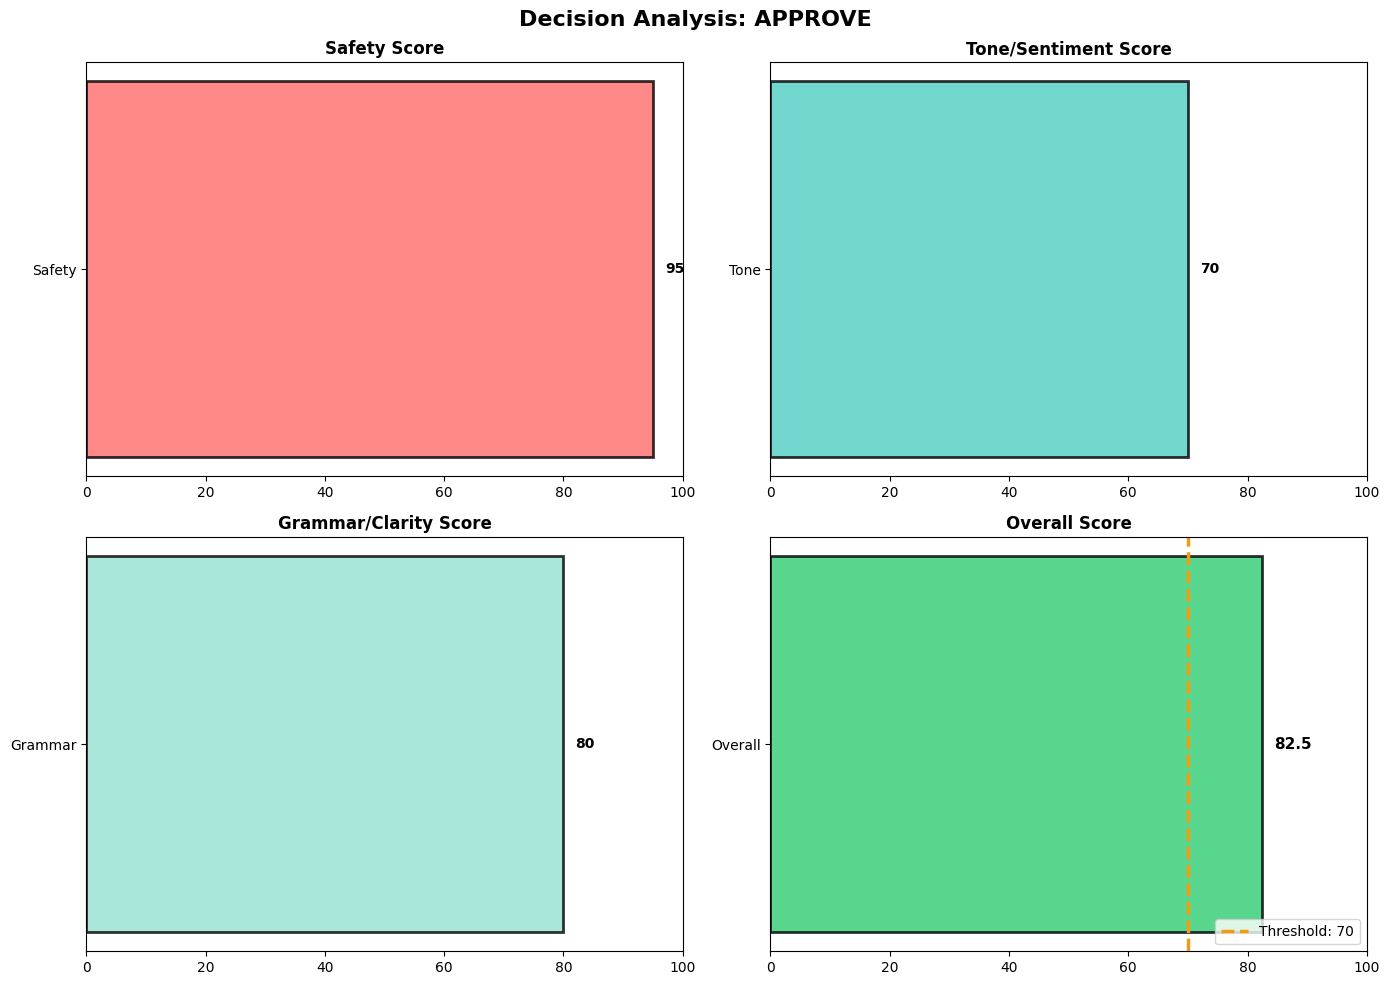


📊 Creating Component Comparison visualization...


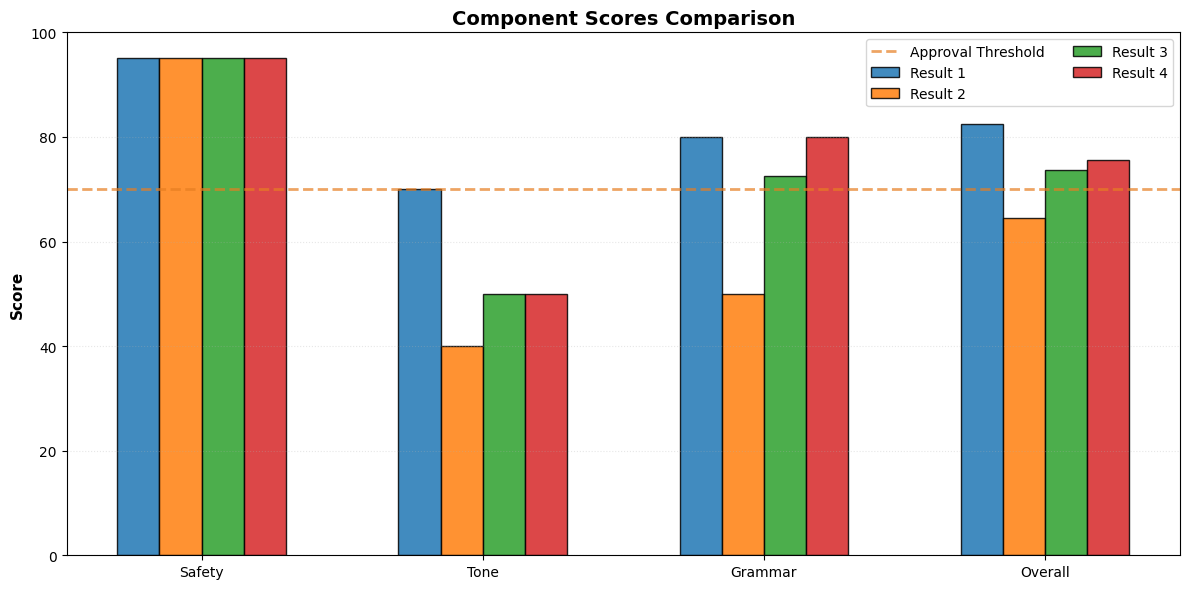


✅ Bonus 4: Explainability Dashboard Complete!
   • Decision breakdown: ✓ Score components visualized
   • Component comparison: ✓ Multi-result analysis displayed
   • Threshold visualization: ✓ Approval boundary shown


In [35]:
print("\n" + "="*80)
print("BONUS 4: EXPLAINABILITY DASHBOARD TEST")
print("="*80)

# Collect results for visualization
expl_test_cases = [
    "This is amazing content! I love it so much!",
    "Terrible article. Completely useless and boring.",
    ("Professional research on machine learning and neural networks. "
     "Key findings show significant improvements in accuracy."),
    "Quick social media update: just finished my project! #excited"
]

expl_results = []

print("\n🎨 Collecting results for visualization...\n")

for i, content in enumerate(expl_test_cases, 1):
    result = run_moderation(content)
    expl_results.append(result)
    print(f"Result {i}: Score {result['overall_score']:.1f} | {result['decision']}")

# Create dashboard
dashboard = ExplainabilityDashboard(expl_results)

print("\n📊 Creating Decision Breakdown visualization...")
fig1 = dashboard.plot_decision_breakdown(0)
plt.show()

print("\n📊 Creating Component Comparison visualization...")
fig2 = dashboard.plot_component_comparison()
plt.show()

print("\n✅ Bonus 4: Explainability Dashboard Complete!")
print("   • Decision breakdown: ✓ Score components visualized")
print("   • Component comparison: ✓ Multi-result analysis displayed")
print("   • Threshold visualization: ✓ Approval boundary shown")


---

## Bonus 5: Iterative Re-evaluation

### Overview
This bonus automatically improves rejected content through iterative re-evaluation and enhancement loops, aiming to reach approval within a maximum number of iterations.

### Objectives
1. Loop evaluation if content is rejected
2. Apply strategic enhancements between iterations
3. Track score improvements over iterations
4. Stop when approved or max iterations reached

### Implementation Pattern
- **Iterative Loop**: Run moderation, enhance if rejected, retry
- **Convergence Stopping**: Exit when approved or limit reached
- **History Tracking**: Store metrics from each iteration
- **Strategic Enhancement**: Improve weak areas based on scores

### Define Iterative Re-evaluator Class

In [38]:
class IterativeReEvaluator:
    """Iteratively evaluates and improves content until approval"""
    
    def __init__(self, max_iterations: int = 3, target_score: float = 90.0):
        self.max_iterations = max_iterations
        self.target_score = target_score
        self.iteration_history = []
    
    def evaluate_and_enhance(self, initial_content: str) -> Dict[str, Any]:
        """Iteratively evaluate and enhance until approved or max iterations"""
        current_content = initial_content
        
        for iteration in range(self.max_iterations):
            # Evaluate current content
            result = run_moderation(current_content)
            score = result.get('overall_score', 0)
            decision = result.get('decision', 'REJECT')
            
            iteration_info = {
                'iteration': iteration + 1,
                'score': score,
                'decision': decision,
                'content_length': len(current_content),
                'safety': result.get('safety_analysis', {}).get('risk_level', 'unknown'),
                'sentiment': result.get('tone_analysis', {}).get('sentiment_score', 50),
                'clarity': result.get('grammar_analysis', {}).get('clarity_score', 50)
            }
            
            self.iteration_history.append(iteration_info)
            
            # Check if approved
            if decision == 'APPROVE' and score >= self.target_score:
                iteration_info['status'] = 'APPROVED'
                return {
                    'final_content': result.get('enhanced_content', current_content),
                    'final_score': score,
                    'iterations_taken': iteration + 1,
                    'history': self.iteration_history,
                    'success': True
                }
            
            # Prepare enhancements for next iteration
            if iteration < self.max_iterations - 1:
                improvements = []
                
                # Strategy 1: Improve negative sentiment
                if result.get('tone_analysis', {}).get('sentiment_score', 50) < 60:
                    current_content = current_content.strip() + " This is genuinely valuable and important content."
                    improvements.append("sentiment")
                
                # Strategy 2: Improve clarity
                if result.get('grammar_analysis', {}).get('clarity_score', 50) < 65:
                    current_content = current_content.strip() + " Let me state this more clearly."
                    improvements.append("clarity")
                
                # Strategy 3: Address safety concerns
                if result.get('safety_analysis', {}).get('risk_level') in ['medium', 'high']:
                    current_content = current_content.strip() + " (with respectful consideration for all perspectives)"
                    improvements.append("safety")
                
                if not improvements:
                    current_content = current_content.strip() + " [Enhanced]"
        
        # Max iterations reached
        final_result = run_moderation(current_content)
        
        return {
            'final_content': final_result.get('enhanced_content', current_content),
            'final_score': final_result.get('overall_score', 0),
            'iterations_taken': self.max_iterations,
            'history': self.iteration_history,
            'success': final_result.get('decision') == 'APPROVE' and final_result.get('overall_score', 0) >= self.target_score
        }

print("✅ IterativeReEvaluator class defined")

✅ IterativeReEvaluator class defined


### Bonus 5: Test Iterative Re-evaluation

In [ ]:
print("\n" + "="*80)
print("BONUS 5: ITERATIVE RE-EVALUATION TEST")
print("="*80)

iter_test_cases = [
    "The article discusses weather patterns and climate systems.",
    "I think the design is really bad and terrible.",
    "This product is okay but could be better in some ways."
]

for i, test_case in enumerate(iter_test_cases, 1):
    print(f"\n{'='*70}")
    print(f"Test Case {i}:")
    print(f"Initial Content: '{test_case[:60]}...'")
    print(f"{'='*70}")
    
    evaluator = IterativeReEvaluator(max_iterations=3, target_score=90.0)
    result = evaluator.evaluate_and_enhance(test_case)
    
    print(f"\n📊 ITERATION DETAILS:")
    for iter_info in result['history']:
        iteration = iter_info['iteration']
        score = iter_info['score']
        decision = iter_info['decision']
        status = f"✓ {iter_info.get('status', '')}" if iter_info.get('status') else decision
        
        print(f"\n  Iteration {iteration}:")
        print(f"    Score: {score:.1f} | Decision: {status}")
        print(f"    Safety: {iter_info['safety']:8s} | Sentiment: {int(iter_info['sentiment']):3d} | Clarity: {int(iter_info['clarity']):3d}")
    
    print(f"\n✅ FINAL RESULT:")
    print(f"  Iterations Used: {result['iterations_taken']}/{evaluator.max_iterations}")
    print(f"  Final Score: {result['final_score']:.1f}")
    print(f"  Status: {'✓ APPROVED ✓' if result['success'] else '✗ NOT APPROVED (max iterations)'}")
    print(f"  Content Length: {len(result['final_content'])} chars")

print("\n" + "="*80)
print("✅ Bonus 5: Iterative Re-evaluation Complete!")
print("="*80)


BONUS 5: ITERATIVE RE-EVALUATION TEST

Test Case 1:
Initial Content: 'The article discusses weather patterns and climate systems....'

📊 ITERATION DETAILS:

  Iteration 1:
    Score: 74.2 | Decision: APPROVE
    Safety: low      | Sentiment:  50 | Clarity:  75

  Iteration 2:
    Score: 73.6 | Decision: APPROVE
    Safety: low      | Sentiment:  50 | Clarity:  72

  Iteration 3:
    Score: 73.4 | Decision: APPROVE
    Safety: low      | Sentiment:  50 | Clarity:  71

✅ FINAL RESULT:
  Iterations Used: 3/3
  Final Score: 73.4
  Status: ✗ NOT APPROVED (max iterations)
  Content Length: 193 chars

Test Case 2:
Initial Content: 'I think the design is really bad and terrible....'

📊 ITERATION DETAILS:

  Iteration 1:
    Score: 68.5 | Decision: REJECT
    Safety: low      | Sentiment:  30 | Clarity:  80

  Iteration 2:
    Score: 67.2 | Decision: REJECT
    Safety: low      | Sentiment:  30 | Clarity:  75

  Iteration 3:
    Score: 66.8 | Decision: REJECT
    Safety: low      | Sentiment: 